# Praktikum Machine Learning - Multiple Features
Multiple Feature, Overfitting, dan Perbaikannya

**Nama:** latihan
**NIM :** _____________________  

Tujuan
Setelah praktikum ini, mahasiswa diharapkan mampu:
1. memahami penggunaan **multiple feature**
2. membedakan **underfitting** dan **overfitting**
3. memperbaiki overfitting dengan **feature selection**
4. melihat dampak **penambahan data**

Petunjuk
- Jalankan cell dari atas ke bawah.
- Kode utama sudah disediakan, fokus praktikum pada **observasi hasil** dan **pemahaman konsep** bukan pada coding.
- Submit file `.ipynb` dan `.pdf` melalui SPADA.
- Penamaan file: NIM_NAMA_multi_fitur.[ipynb/pdf]


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDSEED = 42
np.random.seed(RANDSEED)
plt.rcParams["figure.figsize"] = (7,4)
plt.rcParams["axes.grid"] = True

In [47]:
#Predefined Code
def add_bias(x):
  bias = np.ones(x.shape[0])
  return np.c_[bias, x]

def cost(y,pred, w=None,lamda=0.0):
    m = y.shape[0]
    mse = ((pred - y) ** 2).sum() / (2 * m)
    reg = 0
    if w is not None and lamda!=0.0:
      reg = (lamda / (2 * m)) * (w[1:] ** 2).sum()   # w0 tidak ikut
    return mse + reg

def predict(w,x):
  return x @ w

def update_bobot(w,xb,y,alpha, lamda=0.0):
  output = predict(w,xb)
  error = output-y
  m = y.shape[0]
  #rergularization
  reg = (lamda / m) * w
  reg[0] = 0
  gradient = (xb.T @ error) / m
  w = w - alpha*(gradient+reg)
  return w

def train(X, y, X_val, y_val, alpha=0.1, iters=500, verbose=True, lamda=0.0):
    np.random.seed(RANDSEED)
    w = np.random.randn(X.shape[1]) * 0.01
    history_train = []
    history_val = []

    for i in range(iters):
        pred = predict(w, X)
        loss = cost(y, pred, w, lamda)
        history_train.append(loss)

        pred_val = predict(w, X_val)
        loss_val = cost(y_val, pred_val)
        history_val.append(loss_val)
        if verbose:
          print("Iterasi ke-",i,"  Train Loss: ",loss, "  Val Loss:",loss_val)
        w = update_bobot(w, X, y, alpha, lamda)

    return w, np.array(history_train), np.array(history_val)

def train_test_split(X, y, test_ratio=0.2, seed=RANDSEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    n_test = int(len(y) * test_ratio)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def pilih_sample_random(X, y, n, seed=RANDSEED):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], n, replace=False)
    X_sample = X[idx]
    y_sample = y[idx]
    return X_sample, y_sample

def plot_history_train_validation(hist_train, hist_val):
    plt.plot(hist_train, label="Train Loss")
    plt.plot(hist_val, label="Validation Loss")
    plt.xlabel("Iterasi")
    plt.ylabel("Loss")
    plt.title("Training Curve")
    plt.legend()
    plt.show()

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

##1. Persipan Dataset

###a. Baca Dataset dan Lakukan Preview

In [48]:
#Baca Dataset
data = pd.read_csv("https://drive.google.com/uc?id=16g89ugB-pdYeloUQUhvWLxaIYpTi3e1A")
#Lihat Summary Dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   luas_bangunan_m2            1500 non-null   float64
 1   jumlah_kamar_tidur          1500 non-null   int64  
 2   jarak_ke_pusat_kota_km      1500 non-null   float64
 3   usia_rumah_tahun            1500 non-null   float64
 4   tinggi_pagar_cm             1500 non-null   float64
 5   umur_cat_garasi_tahun       1500 non-null   float64
 6   panjang_gorden_m            1500 non-null   float64
 7   jumlah_tanaman_hias         1500 non-null   int64  
 8   jarak_ke_tiang_listrik_m    1500 non-null   float64
 9   nomor_rumah_digit_terakhir  1500 non-null   int64  
 10  jumlah_dekorasi_dinding     1500 non-null   int64  
 11  tinggi_mailbox_cm           1500 non-null   float64
 12  harga_juta_rupiah           1500 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 152.5 

In [49]:
#Lihat statistik setiap fitur
data.describe()

,luas_bangunan_m2,jumlah_kamar_tidur,jarak_ke_pusat_kota_km,usia_rumah_tahun,tinggi_pagar_cm,umur_cat_garasi_tahun,panjang_gorden_m,jumlah_tanaman_hias,jarak_ke_tiang_listrik_m,nomor_rumah_digit_terakhir,jumlah_dekorasi_dinding,tinggi_mailbox_cm,harga_juta_rupiah
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,109.467493,2.970667,9.126580,11.823460,165.910840,3.980660,1.796220,7.02200,17.966860,4.513333,5.363333,118.635980,469.599053
std,27.866111,1.401112,3.004256,6.695807,18.412331,1.929571,0.407312,4.29315,6.001637,2.822375,3.529253,14.059767,100.873597
min,36.000000,1.000000,1.000000,0.000000,110.000000,0.000000,0.800000,0.00000,2.000000,0.000000,0.000000,70.000000,159.060000
25%,90.990000,2.000000,7.067500,6.937500,153.735000,2.640000,1.530000,3.00000,13.940000,2.000000,2.000000,109.360000,400.972500
50%,110.100000,3.000000,9.120000,11.635000,165.430000,3.900000,1.790000,7.00000,17.975000,5.000000,5.000000,118.295000,468.700000
75%,127.387500,4.000000,11.202500,16.070000,178.512500,5.270000,2.070000,11.00000,21.972500,7.000000,8.000000,128.007500,536.170000
max,199.010000,5.000000,18.270000,36.180000,223.340000,12.000000,3.170000,14.00000,40.000000,9.000000,11.000000,161.410000,773.880000


####PERTANYAAN 1
1. Berapa jumlah data dalam dataset?
2. Jika masalah yang akan diselesaikan adalah prediksi harga rumah, apa nama kolom labelnya?
3. Berapa jumlah fiturnya (tidak termasuk kolom label)?
4. Apakah range setiap fitur sama?

JAWABAN 1 (Jawaban Singkat Saja):
1. 1500
2. harga_juta_rupiah
3. 12
4. berbeda, range tiap fitur berbeda tergantung minimal dan maksimal dari kolom tersebut

###b. Pisahkan Input dan Labelnya

In [50]:
#Pisahkan fitur input dan labelnya
X = data.drop(columns=["harga_juta_rupiah"]).to_numpy()
y = data["harga_juta_rupiah"].to_numpy()
#Lihat Shape dari X dan Y
print(X.shape)
print(y.shape)

(1500, 12)
(1500,)


###c. Lakukan Scaling

Lakukan scaling menggunakan Min-Max Scaling.

$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$

In [51]:
X_min = X.min(axis=0)
X_max = X.max(axis=0)
print("X_min sebelum scaling:", X_min)
print("X_max sebelum scaling:", X_max)

#Lakukan Scaling
X = (X - X_min) / (X_max - X_min)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
print("X_min setelah scaling:", X_min)
print("X_max setelah scaling:", X_max)

X_min sebelum scaling: [ 36.    1.    1.    0.  110.    0.    0.8   0.    2.    0.    0.   70. ]
X_max sebelum scaling: [199.01   5.    18.27  36.18 223.34  12.     3.17  14.    40.     9.
  11.   161.41]
X_min setelah scaling: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
X_max setelah scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


####PERTANYAAN 2
1. Kenapa kita perlu melakukan Scaling?
2. Apa dampaknya jika kita tidak melakukan scaling?

JAWABAN 2:
1. agar prosen konvergensi menjadi lebih cepat dan stabil
2. kalau tidak discaling nanti gradient descentnya akan lambat dan tidak stabil


###d. Tambahkan bias pada X

In [52]:
print('Shape sebelum ditambah bias: ',X.shape)
X = add_bias(X)
print('Shape setelah ditambah bias: ',X.shape)

Shape sebelum ditambah bias:  (1500, 12)
Shape setelah ditambah bias:  (1500, 13)


###e. Lakukan Pemisahan/Split Dataset Menjadi Data Training dan Testing

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y,0.2)
print("Shape Data Training: ", X_train.shape)
print("Shape Data Testing: ", X_test.shape)
print("Shape Label Training: ", y_train.shape)
print("Shape Label Training: ", y_test.shape)

Shape Data Training:  (1200, 13)
Shape Data Testing:  (300, 13)
Shape Label Training:  (1200,)
Shape Label Training:  (300,)


####PERTANYAAN 3
1. Kenapa kita perlu melakukan split dataset menjaid training dan testing?
2. Berapa jumlah data training?
3. Berapa jumlah data testing?
4. Berapa rasio data testing dibanding jml data keseluruhan?

JAWABAN 3:
1. karena kita perlu membedakan data yang digunakan untuk melatih model dan data yang nantinya akan digunakan untuk mengevaluasi performa dan keunggulan dari suatu model
2. 1200
3. 300
4. 0.2

##2. Training Model

###a. Pisahkan Data Training Sungguhan dan Data Validation

In [54]:
X_train_sungguhan, X_val, y_train_sungguhan, y_val = train_test_split(X_train,y_train,0.2)
print("Shape data training: ", X_train_sungguhan.shape)
print("Shape data validation: ", X_val.shape)

Shape data training:  (960, 13)
Shape data validation:  (240, 13)


###b. Training Menggunakan Seluruh Data Training

Iterasi ke- 0   Train Loss:  115489.74437607863   Val Loss: 115401.82447268326
Iterasi ke- 1   Train Loss:  70494.7196806609   Val Loss: 70155.56440383612
Iterasi ke- 2   Train Loss:  43611.816195829866   Val Loss: 43200.87280092955
Iterasi ke- 3   Train Loss:  27525.529953285866   Val Loss: 27114.19897667756
Iterasi ke- 4   Train Loss:  17876.698647422698   Val Loss: 17374.094593128255
Iterasi ke- 5   Train Loss:  12067.640011259506   Val Loss: 11637.650743576336
Iterasi ke- 6   Train Loss:  8550.231559669046   Val Loss: 8040.030063721524
Iterasi ke- 7   Train Loss:  6401.73384235062   Val Loss: 5972.155156289198
Iterasi ke- 8   Train Loss:  5072.055675216969   Val Loss: 4582.673554014706
Iterasi ke- 9   Train Loss:  4233.167297111403   Val Loss: 3812.2814311296092
Iterasi ke- 10   Train Loss:  3689.3750808794257   Val Loss: 3228.6037877770605
Iterasi ke- 11   Train Loss:  3323.858780521228   Val Loss: 2916.1233793881265
Iterasi ke- 12   Train Loss:  3066.814846844135   Val Loss: 2635

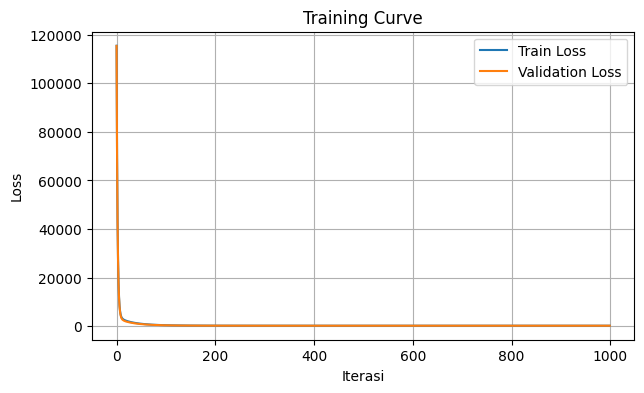

In [74]:
#Training model
w, hist_train, hist_val = train(X_train_sungguhan, y_train_sungguhan, X_val, y_val, 0.5, 1000)

#Plot History Train dan Validation Loss
plot_history_train_validation(hist_train, hist_val)

###c. Lakukan Evaluasi/Testing Menggunakan Data Testing

In [75]:
#Untuk Evaluasi Model, kita gunakan metric Mean Square Error (MSE)

#Evaluasi dengan data training
hasil_prediksi = predict(w,X_train_sungguhan)
error = mse(y_train_sungguhan, hasil_prediksi)
print("Error Trainig: ", error)

#Evaluasi dengan data TEsting
hasil_prediksi = predict(w,X_test)
error = mse(y_test, hasil_prediksi)
print("Error Testing: ", error)

Error Trainig:  313.5095044588865
Error Testing:  319.1725946466458


####PERTANYAAN 4
1. Berapa learning rate dan iterasi yang digunakan?
2. Berapa Error memorization dan generalization yang didapat?
3. Lakukan minimal 5 eksperimen untuk mendapatkan hasil terbaik, dengan mengubah jumlah iterasi dan learning rate, dokumentasikan hasilnya.
4. Berapa Jml iterasi dan Learning Rate yang bisa memberikan hasil/MSE terbaik?

JAWABAN 4:
1. 0.1 dan 500
2. 1618.858738266937 dan 1732.8818959754435
3. Tabel Hasil Eksperimen

| Eksperimen | Jml Iterasi | Learning Rate | MSE Train | MSE Test |
|------------|--------|---------------|-----|-----|
| 1 | 500 | 0.01 | 6164.30654535312 | 6403.555224300892 |
| 2 | 500 | 0.01 | 4371.229253771626 | 4560.567779677058 |
| 3 | 1000 | 0.1 | 360.7342807101133 | 371.5089327263875 |
| 4 | 500 | 0.5 | 315.10953234506985 | 321.1198158826844 |
| 5 | 1000 | 0.5 | 313.5095044588865 | 319.1725946466458 |

4. 1000 dan 0.5

##3. Eksperimen Efek Multiple Feature

###a. Training Model dengan Menggunakan Hanya Fitur 1 dan Evaluasi

**Catatan**: Gunakan Jml Iterasi dan Learning Rate terbaik Pada Hasil Sebelumnya

In [85]:
#Ambil fitur 1 saja
#[0,1] artinya kolom 0 dan 1, kolom 0 selalu kita pakai karena nilai bias
idx_fitur = [0,1,2,3]
X_fitur_1 = X_train_sungguhan[:,idx_fitur]
X_val_fitur_1 =  X_val[:,idx_fitur]
#Train Model
w, hist_train, hist_val = train(X_fitur_1, y_train_sungguhan, X_val_fitur_1, y_val, 0.1, 500)

#Evaluasi dengan data training
hasil_prediksi = predict(w,X_train_sungguhan[:,idx_fitur] )
error = mse(y_train_sungguhan, hasil_prediksi)
print("Error Trainig: ", error)

#Evaluasi dengan data TEsting
hasil_prediksi = predict(w,X_test[:,idx_fitur] )
error = mse(y_test, hasil_prediksi)
print("Error Testing: ", error)

Iterasi ke- 0   Train Loss:  115491.28193775241   Val Loss: 115403.38509535734
Iterasi ke- 1   Train Loss:  80703.17941947767   Val Loss: 80368.85774080834
Iterasi ke- 2   Train Loss:  56652.87576437209   Val Loss: 56171.5977930601
Iterasi ke- 3   Train Loss:  40024.561868145625   Val Loss: 39461.25568784524
Iterasi ke- 4   Train Loss:  28526.352025046017   Val Loss: 27922.717083177256
Iterasi ke- 5   Train Loss:  20574.09585157607   Val Loss: 19956.312561194212
Iterasi ke- 6   Train Loss:  15072.829252419548   Val Loss: 14456.797181061125
Iterasi ke- 7   Train Loss:  11265.713441617972   Val Loss: 10660.596585633913
Iterasi ke- 8   Train Loss:  8629.621672476764   Val Loss: 8040.2363250925055
Iterasi ke- 9   Train Loss:  6802.968839511433   Val Loss: 6231.382043623296
Iterasi ke- 10   Train Loss:  5535.82733679783   Val Loss: 4982.41848929707
Iterasi ke- 11   Train Loss:  4655.447165171058   Val Loss: 4119.605860604813
Iterasi ke- 12   Train Loss:  4042.4234482261973   Val Loss: 3523.

####PERTANYAAN 5
1. Berapa Error Memorization dan Generalization yang didapat?
2. Bandingkan dengan ketika kita gunakan seluruh fiturnya, mana yang lebih baik?
3. Lakukan eksperimen dengan menggunakan kombinasi fitur lainnya, seperti pada tabel berikut, dan catat hasilnya. Gunakan learning rate dan iterasi yang sama.
4. Mana yang terbaik? apa kesimpulan Anda?
5. Mengapa multiple feature dapat membantu?

JAWABAN 5:
1. 319.1725946466458 dan 3883.722088811372
2. yang lebih baik itu yang pake seluruh fitur 
3. Tabel Hasil Eksperimen

| Eksperimen | Fitur |  MSE Train | MSE Test |
|------------|--------|---------------|-----|
| 1 | seluruhnya | 726.9904621226783 | 757.5708333814307 |
| 2 | 1 | 4012.9442451352884 | 3883.722088811372 |
| 3 | 2 | 7264.947976343243 | 7773.850029846284 |
| 4 | 3 | 10030.583028859246 | 9913.222766720019 |
| 6 | 1,2 | 1142.8256569770233 | 1214.2837042783076 |
| 7 | 1,3 | 3676.0039638107787 | 3414.370528417008 |
| 8 | 2,3 | 6985.933177785564 | 7584.885762256488 |
| 9 | 1,2,3 | 750.932347803339 | 797.7887958479042 |

4. yang terbaik adalah yang pake seluruh fitur yaitu 726.9904621226783 dan 757.5708333814307
5. ...

##4. Eksperimen Overfitting dan Underfitting

Data yang kita gunakan adalah data sintesis. Fitur 1-4 merupakan fitur sungguhan, sedangkan fitur sisanya merupakan feature mapping dari fitur fitur sungguhan, bisa berupa kombinasi, atau bahkan pangkat tinggi.

###a. Ambil data training yang tidak terlalu *banyak*

In [86]:
X_train_small, X_val_small, y_train_small, y_val_small = train_test_split(X_train,y_train,0.99)
print("Shape data training: ", X_train_small.shape)
print("Shape data validation: ", X_val_small.shape)

Shape data training:  (12, 13)
Shape data validation:  (1188, 13)


###b. Training model dengan small data dan gunakan fitur-1 saja

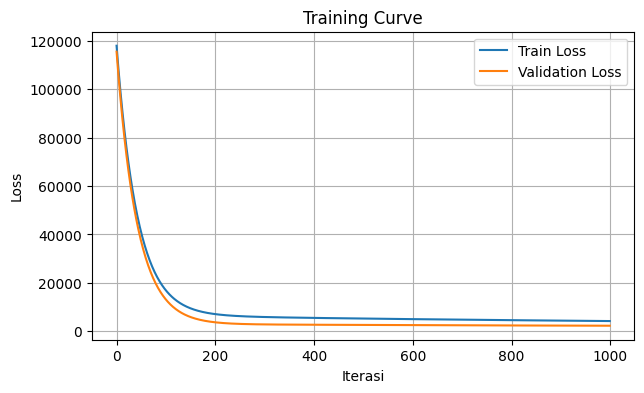

Error Trainig:  8427.370868920381
Error Testing:  4398.0271411596195


In [87]:
#Ambil fitur 1 saja
idx_fitur = [0,1]
#Train Model
w, hist_train, hist_val = train(X_train_small[:,idx_fitur], y_train_small, X_val_small[:,idx_fitur], y_val_small, 0.01, 1000, False)

#Plot History Train dan Validation Loss
plot_history_train_validation(hist_train, hist_val)

#Evaluasi dengan data training
hasil_prediksi = predict(w,X_train_small[:,idx_fitur] )
error = mse(y_train_small, hasil_prediksi)
print("Error Trainig: ", error)

#Evaluasi dengan data TEsting
hasil_prediksi = predict(w,X_test[:,idx_fitur] )
error = mse(y_test, hasil_prediksi)
print("Error Testing: ", error)

###c. Training model dengan small data dan gunakan fitur 1-4

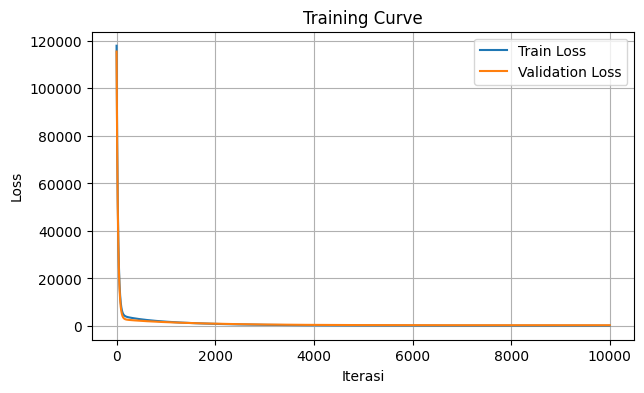

Error Trainig:  257.82024111773904
Error Testing:  735.7506721475415


In [88]:
#Fitur yang digunakan
idx_fitur = [0,1,2,3,4]
#Train Model
w, hist_train, hist_val = train(X_train_small[:,idx_fitur], y_train_small, X_val_small[:,idx_fitur], y_val_small, 0.01, 10000, False)

#Plot History Train dan Validation Loss
plot_history_train_validation(hist_train, hist_val)

#Evaluasi dengan data training
hasil_prediksi = predict(w,X_train_small[:,idx_fitur] )
error = mse(y_train_small, hasil_prediksi)
print("Error Trainig: ", error)

#Evaluasi dengan data TEsting
hasil_prediksi = predict(w,X_test[:,idx_fitur] )
error = mse(y_test, hasil_prediksi)
print("Error Testing: ", error)

###d. Training model dengan small data dan gunakan seluruh fitur

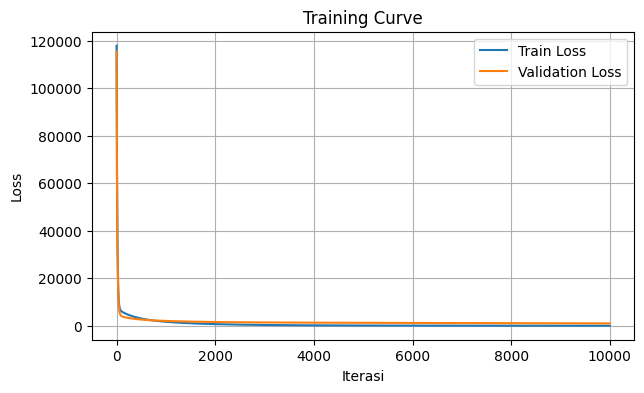

Error Trainig:  156.91291872995868
Error Testing:  2108.67874864009


In [89]:
#Train Model
w, hist_train, hist_val = train(X_train_small, y_train_small, X_val_small, y_val_small, 0.01, 10000, False)

#Plot History Train dan Validation Loss
plot_history_train_validation(hist_train, hist_val)

#Evaluasi dengan data training
hasil_prediksi = predict(w,X_train_small )
error = mse(y_train_small, hasil_prediksi)
print("Error Trainig: ", error)

#Evaluasi dengan data TEsting
hasil_prediksi = predict(w,X_test )
error = mse(y_test, hasil_prediksi)
print("Error Testing: ", error)

####PERTANYAAN 6
1. Berapa Error Memorization dan Generalization yang didapat pada poin b, c, dan d?
2. Masalah apa yang terjadi pada poin b, d, kenapa hasilnya tidak sebaik pada poin c?
3. Berdasarkan pengamatan Anda pada plot history training dan validation apa ciri-ciri gejala underfitting? bagaimana hubungannya dengan jml iterasi, jml data, dan jumlah fitur yang digunakan?
4. Berdasarkan pengamatan Anda pada plot history training dan validation apa ciri-ciri gejala overfitting? bagaimana hubungannya dengan jml iterasi, jml data, dan jumlah fitur yang digunakan?

JAWABAN 6:
1. b. 8427.370868920381 dan 4398.0271411596195
    c. 257.82024111773904 dan 735.7506721475415
    d. 156.91291872995868 dan 2108.67874864009
2. ...
3. ...
4. ...

##5. Eksperimen Feature Selection untuk Memperbaiki Overfitting

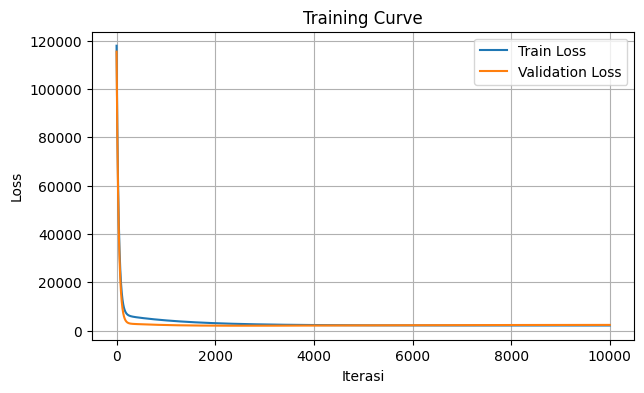

Error Trainig:  4176.035948046695
Error Testing:  4858.017495590012


In [90]:
#Fitur yang digunakan
idx_fitur = [0,1]
#Train Model
w, hist_train, hist_val = train(X_train_small[:,idx_fitur], y_train_small, X_val_small[:,idx_fitur], y_val_small, 0.01, 10000, False)

#Plot History Train dan Validation Loss
plot_history_train_validation(hist_train, hist_val)

#Evaluasi dengan data training
hasil_prediksi = predict(w,X_train_small[:,idx_fitur] )
error = mse(y_train_small, hasil_prediksi)
print("Error Trainig: ", error)

#Evaluasi dengan data TEsting
hasil_prediksi = predict(w,X_test[:,idx_fitur] )
error = mse(y_test, hasil_prediksi)
print("Error Testing: ", error)

####PERTANYAAN 7
**Catatan**: Hanya ubah index fiturnya saja, jangan ubah parameter lain
1. Lakukan sequential forward feature selection (SFS), untuk memilih fitur mana yang terbaik untuk digunakan, dengan cara melakukan training mulai dari 1 fitur, lalu menambahkan fitur yang paling meningkatkan performa model pada setiap langkah hingga semua fitur dicoba. Berdasarkan SFS kombinasi fitur mana yang terbaik?
2. Lakukan sequential backward feature selection (SBFS), untuk memilih fitur mana yang terbaik untuk digunakan, dengan cara melakukan training mulai dari seluruh fitur, lalu menghapus fitur yang paling menurunkan performa model pada setiap langkah hingga semua fitur dicoba. Berdasarkan SBFS kombinasi fitur mana yang terbaik?


JAWABAN 7:
1. ...
2. ...


##6. Eksperimen Regularization untuk Memperbaiki Overfitting

In [ ]:
#Gunakna semua fitur
idx_fitur = [0,1,2,3,4,5,6,7,8,9,10,11,12]
#Train Model
lamda = 0.0 #parameter regularizatio
w, hist_train, hist_val = train(X_train_small[:,idx_fitur], y_train_small, X_val_small[:,idx_fitur], y_val_small, 0.01, 10000, False,lamda)

#Plot History Train dan Validation Loss
plot_history_train_validation(hist_train, hist_val)

#Evaluasi dengan data training
hasil_prediksi = predict(w,X_train_small[:,idx_fitur] )
error = mse(y_train_small, hasil_prediksi)
print("Error Trainig: ", error)

#Evaluasi dengan data TEsting
hasil_prediksi = predict(w,X_test[:,idx_fitur] )
error = mse(y_test, hasil_prediksi)
print("Error Testing: ", error)

####PERTANYAAN 8
**Catatan**: Hanya ubah index fiturnya saja, jangan ubah parameter lain
1. Coba gunakan lamda= 0.0001, 0.001, 0.01, 0.1, 1, 10, 100. Mana yang memberikan hasil terbaik?
2. Apa yang dapat Anda simpulkan?


JAWABAN 8:
1. ...
2. ...

##7. Eksperimen Melihat Efek perubahan jumlah data

In [ ]:
rasio_jml_data_training = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
results = []
#Train dan Test Model dengan jml data training sesuai rasio
for rasio in rasio_jml_data_training:
  jml_data = int(rasio*X_train_sungguhan.shape[0])
  X_train_rasio, y_train_rasio = pilih_sample_random(X_train_sungguhan, y_train_sungguhan, jml_data)
  w, hist_train, hist_val = train(X_train_rasio, y_train_rasio, X_val, y_val, 0.01, 10000, False)

  #Evaluasi dengan data training
  hasil_prediksi = predict(w,X_train_small )
  error_train = mse(y_train_small, hasil_prediksi)

  #Evaluasi dengan data TEsting
  hasil_prediksi = predict(w,X_test )
  error_test = mse(y_test, hasil_prediksi)

  results.append((jml_data, error_train, error_test))

jmls = [r[0] for r in results]
err_train = [r[1] for r in results]
err_test = [r[2] for r in results]

plt.figure(figsize=(8,4))
plt.plot(jmls, err_train, marker="o", label="Train MSE")
plt.plot(jmls, err_test, marker="o", label="Test MSE")
plt.xlabel("Jumlah data train")
plt.ylabel("MSE")
plt.title("Dampak Penambahan Data pada Overfitting")
plt.legend()
plt.show()



####PERTANYAAN 9
1. Berdasarkan grafik, apa kesimpulan Anda terhadap efek penambahan jumlah data terhadap kapasitas model?


JAWABAN 9:
1. ...
